# BigGAN + MidJourney: Cat 4 Classes, IQA Only + XGBoost / MLP

Notebook ini adalah pasangan dari notebook `10`, tetapi sekarang feature set yang dipakai khusus **NR-IQA scalar metrics**:

1. `PIQE`
2. `BRISQUE`
3. `NIQE`

Setup tetap sama:
1. generator: `BigGAN` + `MidJourney`
2. kelas: **4 class kucing yang sama**
3. task: biner `AI vs nature`
4. model: `XGBoost` dan `MLP`

Tujuannya adalah membandingkan apakah metrik IQA tradisional cukup kuat sebagai baseline ketika dua generator digabung pada kelas konten yang sama.



In [1]:
from pathlib import Path
import hashlib
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pyiqa
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

PROJECT_ROOT = Path("..")
MULTICLASS_ROOT = PROJECT_ROOT / "data" / "raw" / "genimage_multiclass_balanced"
DATA_ROOT = MULTICLASS_ROOT / "genimage"
DATA_ROOTS = {
    "BigGAN": DATA_ROOT / "BigGAN" / "train",
    "MidJourney": DATA_ROOT / "MidJourney" / "train",
}
MANIFEST_SOURCE = MULTICLASS_ROOT / "genimage_multiclass_manifest.csv"
CLASS_TABLE_SOURCE = MULTICLASS_ROOT / "genimage_multiclass_classes.csv"
IMAGENET_MAP = PROJECT_ROOT / "data" / "imagenet_class_index.json"
MANIFEST_OUT = PROJECT_ROOT / "data" / "genimage_manifest_biggan_midjourney_multiclass_train.csv"
IQA_OUT = PROJECT_ROOT / "artifacts" / "features_iqa_biggan_midjourney_multiclass_train.csv"
VECTOR_OUT = PROJECT_ROOT / "artifacts" / "feature_vector_biggan_midjourney_multiclass_iqa_only.csv"
METRICS_OUT = PROJECT_ROOT / "artifacts" / "results_classification_biggan_midjourney_multiclass_iqa_only.csv"
PRED_OUT = PROJECT_ROOT / "artifacts" / "predictions_classification_biggan_midjourney_multiclass_iqa_only.csv"

print("Data root:", DATA_ROOT.resolve())
print("Manifest source:", MANIFEST_SOURCE.resolve())


/home/nanda/miniconda3/envs/ai/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data root: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage
Manifest source: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage_multiclass_manifest.csv


## 1. Audit data per generator

In [2]:
manifest_source = pd.read_csv(MANIFEST_SOURCE)
class_table = pd.read_csv(CLASS_TABLE_SOURCE)

manifest_source["path_exists"] = manifest_source["path"].map(lambda p: Path(p).is_file())
print("Manifest source:", MANIFEST_SOURCE.resolve())
print("Class table:", CLASS_TABLE_SOURCE.resolve())
print("Manifest shape:", manifest_source.shape)
print("Jumlah kelas:", manifest_source["imagenet_id"].nunique())
print("Semua path ada:", bool(manifest_source["path_exists"].all()))

display(class_table.head(10))
display(
    manifest_source
    .groupby(["generator", "class_name"])
    .size()
    .rename("count")
    .reset_index()
)
display(
    manifest_source
    .groupby(["generator", "class_name", "imagenet_id", "wordnet_id", "content_label"])
    .size()
    .rename("count")
    .reset_index()
    .describe(include="all")
)


Manifest source: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage_multiclass_manifest.csv
Class table: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage_multiclass_balanced/genimage_multiclass_classes.csv
Manifest shape: (8000, 16)
Jumlah kelas: 40
Semua path ada: True


,class_id,class_id_str,wnid,label
0,0,0,n01440764,tench
1,1,1,n01443537,goldfish
2,2,2,n01484850,great_white_shark
3,3,3,n01491361,tiger_shark
4,4,4,n01494475,hammerhead
5,5,5,n01496331,electric_ray
6,6,6,n01498041,stingray
7,7,7,n01514668,cock
8,8,8,n01514859,hen
9,9,9,n01518878,ostrich


,generator,class_name,count
0,BigGAN,ai,2000
1,BigGAN,nature,2000
2,MidJourney,ai,2000
3,MidJourney,nature,2000


,generator,class_name,imagenet_id,wordnet_id,content_label,count
count,160,160,160.000000,160,160,160.0
unique,2,2,NaN,40,40,NaN
top,BigGAN,ai,NaN,n01440764,tench,NaN
freq,80,80,NaN,4,4,NaN
mean,NaN,NaN,112.925000,NaN,NaN,50.0
std,NaN,NaN,131.508019,NaN,NaN,0.0
min,NaN,NaN,0.000000,NaN,NaN,50.0
25%,NaN,NaN,9.750000,NaN,NaN,50.0
50%,NaN,NaN,59.500000,NaN,NaN,50.0
75%,NaN,NaN,207.250000,NaN,NaN,50.0


## 2. Bangun manifest gabungan untuk 4 class kucing yang sama


In [3]:
manifest = pd.read_csv(MANIFEST_SOURCE).copy()
manifest["subset_name"] = "biggan_midjourney_multiclass_train"
manifest["split"] = "train"
manifest["path"] = manifest["path"].map(lambda p: str(Path(p).resolve()))

missing_paths = manifest.loc[~manifest["path"].map(lambda p: Path(p).is_file()), "path"].head()
if len(missing_paths):
    raise FileNotFoundError(
        "Ada path manifest yang tidak ditemukan, contoh: "
        + str(missing_paths.tolist())
    )

manifest.to_csv(MANIFEST_OUT, index=False)
print("Saved manifest:", MANIFEST_OUT.resolve())
print("Manifest shape:", manifest.shape)
display(manifest.head())
display(manifest.groupby(["generator", "y_ai"]).size().rename("count").reset_index())
display(
    manifest
    .groupby(["generator", "class_name", "content_label"])
    .size()
    .rename("count")
    .reset_index()
    .head(20)
)


Saved manifest: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/genimage_manifest_biggan_midjourney_multiclass_train.csv
Manifest shape: (8000, 15)


,image_id,path,relative_path,archive_path,internal_path,generator,subset_name,split,class_name,content_id,content_label,imagenet_id,wordnet_id,is_real,y_ai
0,BigGAN_ai_000_000000,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00037.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
1,BigGAN_ai_000_000001,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00007.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
2,BigGAN_ai_000_000002,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00086.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
3,BigGAN_ai_000_000003,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00077.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1
4,BigGAN_ai_000_000004,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00070.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1


,generator,y_ai,count
0,BigGAN,0,2000
1,BigGAN,1,2000
2,MidJourney,0,2000
3,MidJourney,1,2000


,generator,class_name,content_label,count
0,BigGAN,ai,Chesapeake_Bay_retriever,50
1,BigGAN,ai,Chihuahua,50
2,BigGAN,ai,Egyptian_cat,50
3,BigGAN,ai,German_short-haired_pointer,50
4,BigGAN,ai,Labrador_retriever,50
5,BigGAN,ai,Persian_cat,50
6,BigGAN,ai,Siamese_cat,50
7,BigGAN,ai,ambulance,50
8,BigGAN,ai,beach_wagon,50
9,BigGAN,ai,black_swan,50


## 3. Ekstraksi metrik IQA: PIQE, BRISQUE, NIQE
Notebook ini memakai `pyiqa` secara langsung. Ketiga metrik ini scalar, jadi feature vector nantinya hanya 3 dimensi.

In [4]:
if IQA_OUT.exists():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Loaded existing IQA features later; skip IQA metric initialization.")
else:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    metric_piqe = pyiqa.create_metric("piqe", device=device)
    metric_brisque = pyiqa.create_metric("brisque", device=device)
    metric_niqe = pyiqa.create_metric("niqe", device=device)
    print("device:", device)


device: cpu


In [5]:
if IQA_OUT.exists():
    iqa_df = pd.read_csv(IQA_OUT)
    print("Loaded existing IQA features:", IQA_OUT.resolve())
else:
    from PIL import Image

    IQA_CACHE_DIR = IQA_OUT.parent / "_iqa_safe_images_multiclass"
    IQA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    MIN_IQA_SIDE = 256

    def make_iqa_safe_image(path: str) -> str:
        """NIQE needs enough spatial support; upsample small images to avoid zero-size blocks."""
        src = Path(path)
        img = Image.open(src).convert("RGB")
        w, h = img.size

        if min(w, h) >= MIN_IQA_SIDE:
            return str(src)

        scale = MIN_IQA_SIDE / min(w, h)
        new_size = (int(round(w * scale)), int(round(h * scale)))
        safe_path = IQA_CACHE_DIR / f"{src.stem}_{new_size[0]}x{new_size[1]}.png"

        if not safe_path.exists():
            img = img.resize(new_size, Image.Resampling.BICUBIC)
            img.save(safe_path)

        return str(safe_path)

    def extract_iqa_scores(path: str):
        safe_path = make_iqa_safe_image(path)
        with torch.no_grad():
            piqe = float(metric_piqe(safe_path).item())
            brisque = float(metric_brisque(safe_path).item())
            niqe = float(metric_niqe(safe_path).item())
        return {
            "piqe": piqe,
            "brisque": brisque,
            "niqe": niqe,
        }

    iqa_rows = []
    iqa_errors = []

    for idx, row in enumerate(manifest.itertuples(index=False), start=1):
        try:
            scores = extract_iqa_scores(row.path)
            iqa_rows.append({"image_id": row.image_id, **scores})
        except Exception as exc:
            iqa_errors.append({
                "image_id": row.image_id,
                "path": row.path,
                "error": repr(exc),
            })

        if idx % 100 == 0:
            print(f"Processed IQA {idx}/{len(manifest)} images")

    if iqa_errors:
        err_df = pd.DataFrame(iqa_errors)
        err_out = IQA_OUT.parent / "features_iqa_errors_biggan_midjourney_multiclass_train.csv"
        err_df.to_csv(err_out, index=False)
        print("IQA errors:", len(iqa_errors))
        print("Saved IQA error log:", err_out.resolve())
        display(err_df.head())

    if not iqa_rows:
        raise RuntimeError("No IQA features were extracted. Check the IQA error log.")

    iqa_df = pd.DataFrame(iqa_rows)
    iqa_df.to_csv(IQA_OUT, index=False)
    print("Saved IQA features:", IQA_OUT.resolve())

display(iqa_df.head())


Processed 100/8000 images
Processed 200/8000 images
Processed 300/8000 images
Processed 400/8000 images
Processed 500/8000 images
Processed 600/8000 images
Processed 700/8000 images
Processed 800/8000 images
Processed 900/8000 images
Processed 1000/8000 images
Processed 1100/8000 images
Processed 1200/8000 images
Processed 1300/8000 images
Processed 1400/8000 images
Processed 1500/8000 images
Processed 1600/8000 images
Processed 1700/8000 images
Processed 1800/8000 images
Processed 1900/8000 images
Processed 2000/8000 images
Processed 2100/8000 images
Processed 2200/8000 images
Processed 2300/8000 images
Processed 2400/8000 images
Processed 2500/8000 images
Processed 2600/8000 images
Processed 2700/8000 images
Processed 2800/8000 images
Processed 2900/8000 images
Processed 3000/8000 images
Processed 3100/8000 images
Processed 3200/8000 images
Processed 3300/8000 images
Processed 3400/8000 images
Processed 3500/8000 images
Processed 3600/8000 images
Processed 3700/8000 images
Processed 

,image_id,piqe,brisque,niqe
0,BigGAN_ai_000_000000,42.487041,36.240234,4.933562
1,BigGAN_ai_000_000001,50.800961,36.021912,5.641158
2,BigGAN_ai_000_000002,41.170307,44.712158,4.913123
3,BigGAN_ai_000_000003,41.735916,37.302612,5.203913
4,BigGAN_ai_000_000004,41.149288,41.458374,4.682221


## 4. Bangun feature vector IQA only

In [6]:
data = manifest.merge(iqa_df, on="image_id", how="inner")
meta_cols = ["image_id", "path", "relative_path", "generator", "subset_name", "split", "class_name", "content_id", "content_label", "is_real", "y_ai"]
feature_cols = ["piqe", "brisque", "niqe"]

data.to_csv(VECTOR_OUT, index=False)
print("Merged shape:", data.shape)
print("Feature dims:", len(feature_cols))
print("Saved vector:", VECTOR_OUT.resolve())
display(data.head())

Merged shape: (8000, 18)
Feature dims: 3
Saved vector: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/feature_vector_biggan_midjourney_multiclass_iqa_only.csv


,image_id,path,relative_path,archive_path,internal_path,generator,subset_name,split,class_name,content_id,content_label,imagenet_id,wordnet_id,is_real,y_ai,piqe,brisque,niqe
0,BigGAN_ai_000_000000,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00037.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1,42.487041,36.240234,4.933562
1,BigGAN_ai_000_000001,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00007.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1,50.800961,36.021912,5.641158
2,BigGAN_ai_000_000002,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00086.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1,41.170307,44.712158,4.913123
3,BigGAN_ai_000_000003,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00077.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1,41.735916,37.302612,5.203913
4,BigGAN_ai_000_000004,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN/train/ai/000_biggan_00070.png,/content/drive/MyDrive/BigGAN/imagenet_ai_0419...,imagenet_ai_0419_biggan/train/ai/000_biggan_00...,BigGAN,biggan_midjourney_multiclass_train,train,ai,000,tench,0,n01440764,False,1,41.149288,41.458374,4.682221


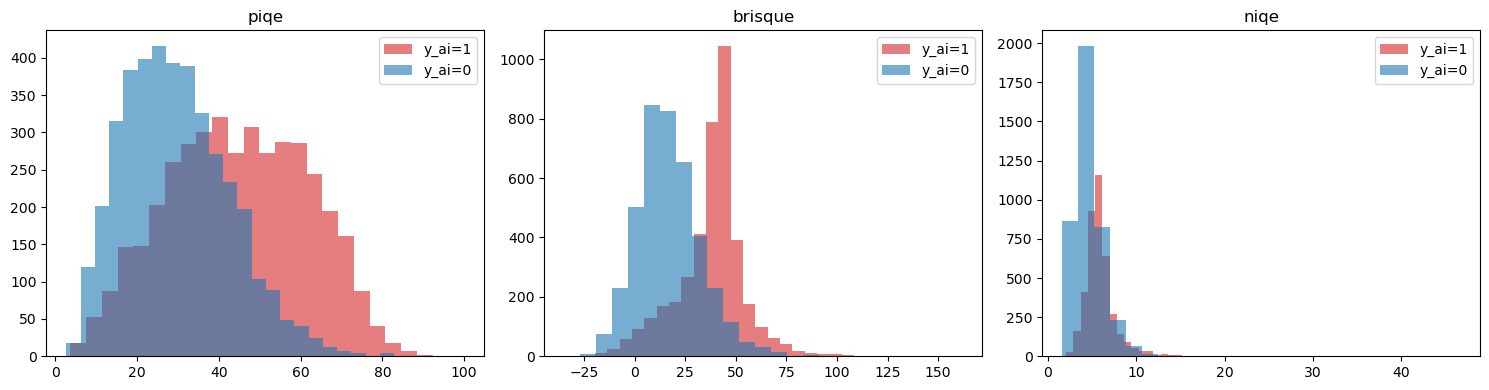

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, feature_cols):
    for label, color in [(1, "tab:red"), (0, "tab:blue")]:
        ax.hist(data[data["y_ai"] == label][col], bins=25, alpha=0.6, label=f"y_ai={label}", color=color)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

## 5. Split 80:20 dengan stratifikasi gabungan

In [8]:
X = data[feature_cols].to_numpy(dtype=np.float32)
y = data["y_ai"].to_numpy(dtype=np.int64)
stratify_key = data["generator"].astype(str) + "|" + data["y_ai"].astype(str) + "|" + data["content_label"].astype(str)

X_train, X_eval, y_train, y_eval, train_idx, eval_idx = train_test_split(
    X, y, data.index.to_numpy(), test_size=0.2, random_state=42, stratify=stratify_key
)

print("Train:", X_train.shape, y_train.shape)
print("Eval:", X_eval.shape, y_eval.shape)

Train: (6400, 3) (6400,)
Eval: (1600, 3) (1600,)


## 6. Train baseline dengan IQA only

In [9]:
models = {
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
    ),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=(32, 16), activation="relu", max_iter=500, random_state=42)),
    ]),
}

results = []
pred_store = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    score_ai = model.predict_proba(X_eval)[:, 1]
    pred_ai = (score_ai >= 0.5).astype(np.int64)
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_eval, pred_ai),
        "f1": f1_score(y_eval, pred_ai),
        "auroc": roc_auc_score(y_eval, score_ai),
    })
    pred_store[name] = {"score_ai": score_ai, "pred_ai": pred_ai}

results_df = pd.DataFrame(results).sort_values(by=["auroc", "f1", "accuracy"], ascending=False).reset_index(drop=True)
display(results_df)

,model,accuracy,f1,auroc
0,MLP,0.809375,0.807084,0.873019
1,XGBoost,0.806250,0.802043,0.866692


## 7. Confusion matrix model terbaik

Best model: MLP

              precision    recall  f1-score   support

      nature       0.80      0.82      0.81       800
          ai       0.82      0.80      0.81       800

    accuracy                           0.81      1600
   macro avg       0.81      0.81      0.81      1600
weighted avg       0.81      0.81      0.81      1600



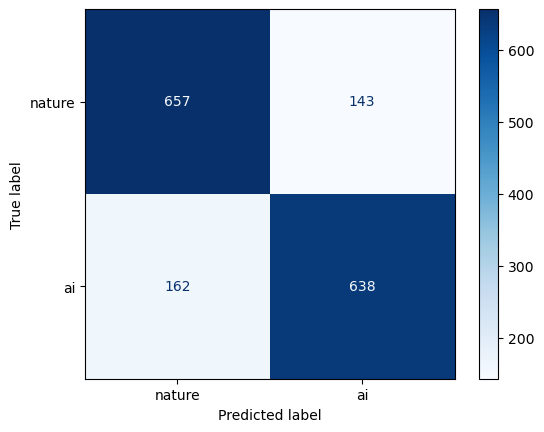

In [10]:
best_model = results_df.iloc[0]["model"]
print("Best model:", best_model)
print()
print(classification_report(y_eval, pred_store[best_model]["pred_ai"], target_names=["nature", "ai"]))
cm = confusion_matrix(y_eval, pred_store[best_model]["pred_ai"])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["nature", "ai"]).plot(cmap="Blues")
plt.show()

## 8. Simpan hasil

In [11]:
metrics_df = results_df.copy()
metrics_df["feature_set"] = "iqa_only"
metrics_df["iqa_metrics"] = "piqe,brisque,niqe"
metrics_df["split_protocol"] = "train_holdout_80_20_stratified_generator_label_class"
metrics_df["subset_name"] = "biggan_midjourney_multiclass_train"
metrics_df["n_total"] = len(data)
metrics_df["n_train"] = len(X_train)
metrics_df["n_eval"] = len(X_eval)
metrics_df.to_csv(METRICS_OUT, index=False)

base_eval = data.iloc[eval_idx][["image_id", "path", "generator", "class_name", "content_id", "content_label", "y_ai"]].copy()
pred_parts = []
for name, pred in pred_store.items():
    part = base_eval.copy()
    part["model"] = name
    part["score_ai"] = pred["score_ai"]
    part["pred_ai"] = pred["pred_ai"]
    pred_parts.append(part)

pred_df = pd.concat(pred_parts, ignore_index=True)
pred_df.to_csv(PRED_OUT, index=False)

print("Saved metrics:", METRICS_OUT.resolve())
print("Saved predictions:", PRED_OUT.resolve())
display(metrics_df)
display(pred_df.head())


Saved metrics: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/results_classification_biggan_midjourney_multiclass_iqa_only.csv
Saved predictions: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/predictions_classification_biggan_midjourney_multiclass_iqa_only.csv


,model,accuracy,f1,auroc,feature_set,iqa_metrics,split_protocol,subset_name,n_total,n_train,n_eval
0,MLP,0.809375,0.807084,0.873019,iqa_only,"piqe,brisque,niqe",train_holdout_80_20_stratified_generator_label...,biggan_midjourney_multiclass_train,8000,6400,1600
1,XGBoost,0.806250,0.802043,0.866692,iqa_only,"piqe,brisque,niqe",train_holdout_80_20_stratified_generator_label...,biggan_midjourney_multiclass_train,8000,6400,1600


,image_id,path,generator,class_name,content_id,content_label,y_ai,model,score_ai,pred_ai
0,BigGAN_nature_436_003899,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,nature,n02814533,beach_wagon,0,XGBoost,0.801228,1
1,MidJourney_ai_107_006446,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,MidJourney,ai,107,jellyfish,1,XGBoost,0.321309,0
2,BigGAN_ai_014_001413,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,ai,014,indigo_bunting,1,XGBoost,0.869848,1
3,BigGAN_ai_102_002207,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,ai,102,echidna,1,XGBoost,0.942678,1
4,BigGAN_nature_016_001690,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,nature,n01560419,bulbul,0,XGBoost,0.148380,0


## 9. Catatan interpretasi
Notebook ini sebaiknya dibaca bersama notebook `08`, `09`, dan `10`:
1. `08` = FFT only
2. `09` = FFT + CLIP
3. `10` = CLIP only
4. `11` = IQA only

Dengan empat notebook ini, kita bisa membandingkan keluarga fitur spektral, semantik, dan NR-IQA pada setup dua generator dan empat class yang sama.